# AI translation validation check - model
Romain Darous
Exploration the LLM BERT

In [1]:
from transformers import BertTokenizer

# Initialize the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def inspect_tokens(text):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt')
    
    # Get the token IDs
    token_ids = inputs['input_ids'].squeeze().tolist()
    
    # Convert token IDs to tokens
    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    
    # Print the tokens and their corresponding IDs
    for token_id, token in zip(token_ids, tokens):
        print(f"Token ID: {token_id}, Token: {token}")
    return tokens

# Example usage
text = "Hello, how are you?"
inspect_tokens(text)


c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Token ID: 101, Token: [CLS]
Token ID: 31178, Token: Hello
Token ID: 117, Token: ,
Token ID: 14796, Token: how
Token ID: 10301, Token: are
Token ID: 13028, Token: you
Token ID: 136, Token: ?
Token ID: 102, Token: [SEP]


c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


['[CLS]', 'Hello', ',', 'how', 'are', 'you', '?', '[SEP]']

In [2]:
from transformers import BertTokenizer, BertModel
import torch

# Load the tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model = BertModel.from_pretrained('bert-base-multilingual-cased')


c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renam

(8, 768)
(10, 768)
Token ID: 101, Token: [CLS]
Token ID: 11763, Token: Hall
Token ID: 10133, Token: ##o
Token ID: 117, Token: ,
Token ID: 10953, Token: wie
Token ID: 15329, Token: get
Token ID: 10196, Token: es
Token ID: 15895, Token: dir
Token ID: 136, Token: ?
Token ID: 102, Token: [SEP]
Token ID: 101, Token: [CLS]
Token ID: 146, Token: I
Token ID: 10149, Token: do
Token ID: 10472, Token: not
Token ID: 11850, Token: like
Token ID: 13028, Token: you
Token ID: 119, Token: .
Token ID: 102, Token: [SEP]


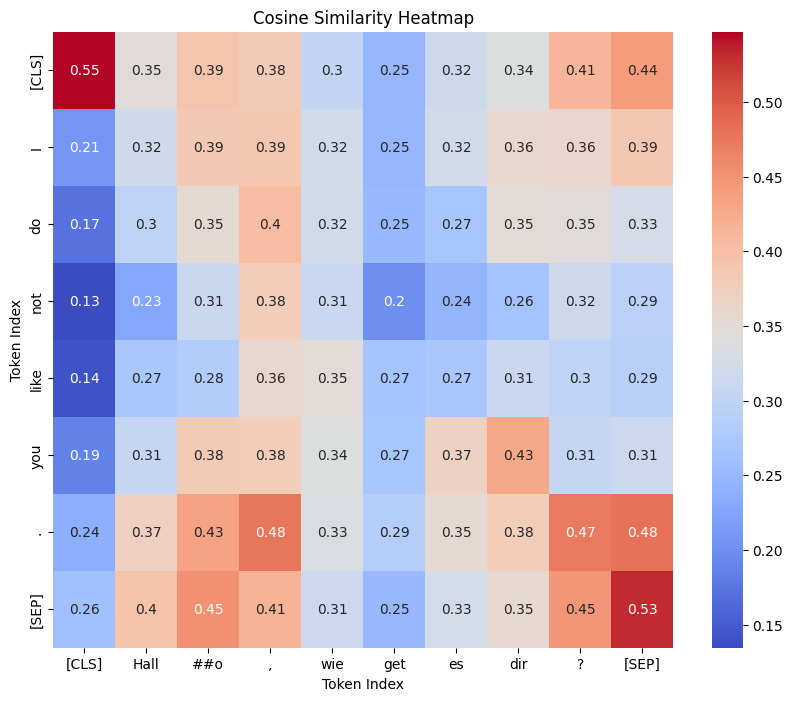

In [33]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from sklearn.metrics import confusion_matrix

def get_word_embeddings(text):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt')

    # Forward pass through the model
    with torch.no_grad():
        outputs = model(**inputs)

    # The embeddings are in the last_hidden_state
    embeddings = outputs.last_hidden_state

    # Convert embeddings to a list of numpy arrays
    embeddings_np = embeddings.squeeze().numpy()

    return embeddings_np

# Example usage
text_1 = "I do not like you."
embeddings_1 = get_word_embeddings(text_1)

print(embeddings_1.shape)  # Shape: (number of tokens, embedding dimension)

# Another example
text_2 = "Hallo, wie get es dir?"
embeddings_2 = get_word_embeddings(text_2)

print(embeddings_2.shape)  # Shape: (number of tokens, embedding dimension)


# Compute cosine similarity between embeddings_1 and embeddings_2
cos_sim = cosine_similarity(embeddings_1, embeddings_2)

import matplotlib.pyplot as plt

# Get the number of tokens
num_tokens = embeddings_1.shape[0]

# Create a list  words

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cos_sim, annot=True, cmap='coolwarm', xticklabels=inspect_tokens(text_2), yticklabels=inspect_tokens(text_1))
plt.xlabel('Token Index')
plt.ylabel('Token Index')
plt.title('Cosine Similarity Heatmap')
plt.show()


### Naive sentence embedding

In [34]:
import numpy as np
sent_1 = np.mean(embeddings_1, axis = 0)
sent_2 = np.mean(embeddings_2, axis=0)

# Computing cosine similarity between sentences
cos_sim_sentences = cosine_similarity(sent_1.reshape(1, -1), sent_2.reshape(1, -1))
print(f"Cosine Similarity between sentences: {cos_sim_sentences[0][0]}")

Cosine Similarity between sentences: 0.4869728684425354


### Improving embedding
Idea : starting from a naive embedding, build a model that classifies whether or not the translations are close to each other.